In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from features import common_preprocessing, get_datasets
from utils import process_fx


In [3]:
X_input, X_primary, X_aux, X_orig, Y_train = get_datasets()
target_pairs = pd.read_csv("data/target_pairs.csv")


Dropping columns:  ['US_Stock_GOLD_adj_open', 'US_Stock_GOLD_adj_high', 'US_Stock_GOLD_adj_low', 'US_Stock_GOLD_adj_close', 'US_Stock_GOLD_adj_volume', 'JPX_Gold_Mini_Futures_settlement_price', 'JPX_Gold_Rolling-Spot_Futures_settlement_price', 'JPX_Platinum_Mini_Futures_settlement_price', 'JPX_RSS3_Rubber_Futures_settlement_price']
Found 505 relevant columns
Only close column provided for stem lme_ah
Only close column provided for stem lme_ca
Only close column provided for stem lme_pb
Only close column provided for stem lme_zs


In [4]:
print(X_input.shape)
print(X_primary.shape)
print(X_aux.shape)
print(Y_train.shape)
print(target_pairs.shape)


(1871, 606)
(1871, 103)
(1871, 501)
(1871, 425)
(424, 3)


In [5]:
from collections import Counter

target_counter = Counter()
for _, row in target_pairs.iterrows():
    legs = row["pair"].split(" - ")
    target_counter.update(legs)

target_counter


Counter({'LME_AH_Close': 81,
         'LME_ZS_Close': 76,
         'JPX_Gold_Standard_Futures_Close': 74,
         'JPX_Platinum_Standard_Futures_Close': 71,
         'LME_CA_Close': 70,
         'LME_PB_Close': 68,
         'US_Stock_VT_adj_close': 5,
         'FX_ZARUSD': 5,
         'FX_NOKEUR': 5,
         'US_Stock_VXUS_adj_close': 5,
         'US_Stock_VYM_adj_close': 4,
         'US_Stock_IEMG_adj_close': 4,
         'FX_AUDJPY': 4,
         'US_Stock_VGIT_adj_close': 4,
         'FX_EURAUD': 4,
         'FX_CADCHF': 4,
         'FX_ZARCHF': 4,
         'FX_NZDJPY': 4,
         'FX_CHFJPY': 4,
         'US_Stock_VTV_adj_close': 4,
         'US_Stock_OIH_adj_close': 4,
         'FX_USDJPY': 4,
         'FX_AUDCHF': 4,
         'US_Stock_SLV_adj_close': 4,
         'US_Stock_BKR_adj_close': 4,
         'FX_GBPJPY': 4,
         'US_Stock_URA_adj_close': 4,
         'US_Stock_VEA_adj_close': 4,
         'FX_ZARJPY': 4,
         'US_Stock_OKE_adj_close': 4,
         'US_Stock_CVX_adj

In [6]:
target_pairs


,target,lag,pair
0,target_0,1,US_Stock_VT_adj_close
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close
2,target_2,1,LME_CA_Close - LME_ZS_Close
3,target_3,1,LME_AH_Close - LME_ZS_Close
4,target_4,1,LME_AH_Close - JPX_Gold_Standard_Futures_Close
...,...,...,...
419,target_419,4,FX_NOKUSD - LME_AH_Close
420,target_420,4,JPX_Gold_Standard_Futures_Close - US_Stock_RY_...
421,target_421,4,US_Stock_EWT_adj_close - LME_AH_Close
422,target_422,4,JPX_Platinum_Standard_Futures_Close - FX_NOKCHF


## Find important features for a given target

In [19]:
target_col = "LME_AH_Close"
lag = 4

target_values = np.log(
    X_orig[target_col].shift(-lag - 1) / X_orig[target_col].shift(-1)
).fillna(0)


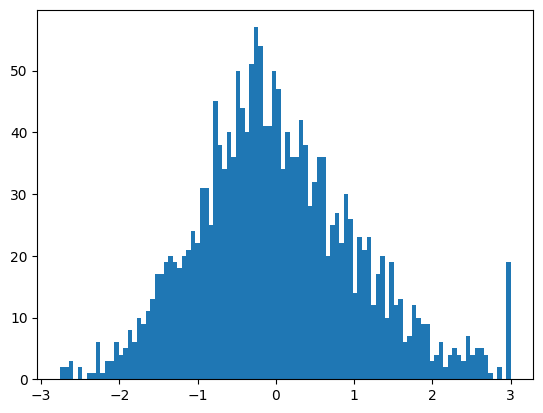

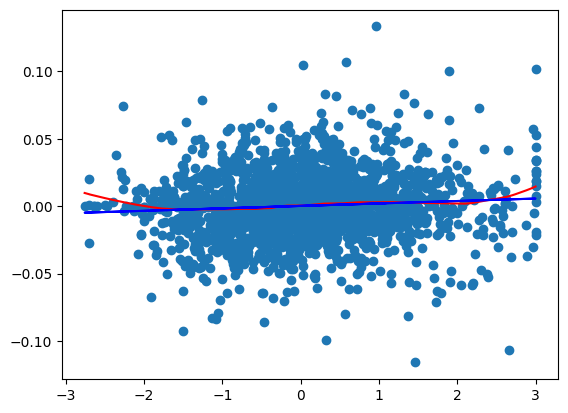

In [ ]:
from supersmoother import SuperSmoother

feature_col = "us_stock_iau_adj_volume"
feature_values = X_input[feature_col].values

trend = SuperSmoother().fit(feature_values, target_values).predict(feature_values)
linear_trend = np.polyfit(feature_values, target_values, 1)
perm = np.argsort(feature_values)
plt.hist(feature_values, bins=100)
plt.show()
plt.scatter(feature_values, target_values)
plt.plot(feature_values[perm], trend[perm], color="red")
plt.plot(
    feature_values, linear_trend[0] * feature_values + linear_trend[1], color="blue"
)
plt.show()


In [29]:
import dcor
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

pearson_list = []
spearman_list = []

for col in X_input.columns:
    x = X_input[col].values
    y = target_values.values
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() == 0:
        pearson = np.nan
        spearman = np.nan
    else:
        pearson = abs(pearsonr(x[valid], y[valid])[0])
        spearman = abs(spearmanr(x[valid], y[valid]).statistic)
    pearson_list.append(pearson)
    spearman_list.append(spearman)

feature_stats_df = pd.DataFrame(
    {
        "feature": X_input.columns,
        "pearson": pearson_list,
        "spearman": spearman_list,
    }
).set_index("feature")
feature_stats_df = feature_stats_df.sort_values(by="spearman", ascending=False)

feature_stats_df.to_csv("feature_stats.csv")
